C:\ProgramData\anaconda3\Lib\site-packages\torchvision\models\_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
C:\ProgramData\anaconda3\Lib\site-packages\torchvision\models\_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=EfficientNet_B0_Weights.IMAGENET1K_V1`. You can also use `weights=EfficientNet_B0_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
C:\ProgramData\anaconda3\Lib\site-packages\transformers\models\vit\feature_extraction_vit.py:28: FutureWarning: The class ViTFeatureExtractor is deprecated and will be removed in version 5 of Transformers. Please use ViTImageProcessor instead.
  warnings.warn(


EfficientNet - Epoch 1: Train Loss: 1.1629, Train Acc: 0.4690, Val Acc: 0.5636
EfficientNet - Epoch 2: Train Loss: 0.9539, Train Acc: 0.5902, Val Acc: 0.6314
EfficientNet - Epoch 3: Train Loss: 0.8769, Train Acc: 0.6439, Val Acc: 0.6512
EfficientNet - Epoch 4: Train Loss: 0.8421, Train Acc: 0.6518, Val Acc: 0.6843
EfficientNet - Epoch 5: Train Loss: 0.7866, Train Acc: 0.6803, Val Acc: 0.7405
EfficientNet - Epoch 6: Train Loss: 0.7451, Train Acc: 0.7022, Val Acc: 0.7421
EfficientNet - Epoch 7: Train Loss: 0.7062, Train Acc: 0.7167, Val Acc: 0.7537
EfficientNet - Epoch 8: Train Loss: 0.7159, Train Acc: 0.7142, Val Acc: 0.7570
EfficientNet - Epoch 9: Train Loss: 0.6969, Train Acc: 0.7208, Val Acc: 0.7818
EfficientNet - Epoch 10: Train Loss: 0.6664, Train Acc: 0.7436, Val Acc: 0.7405
EfficientNet - Epoch 11: Train Loss: 0.6890, Train Acc: 0.7308, Val Acc: 0.7587
EfficientNet - Epoch 12: Train Loss: 0.6476, Train Acc: 0.7502, Val Acc: 0.7719
EfficientNet - Epoch 13: Train Loss: 0.6319, Trai

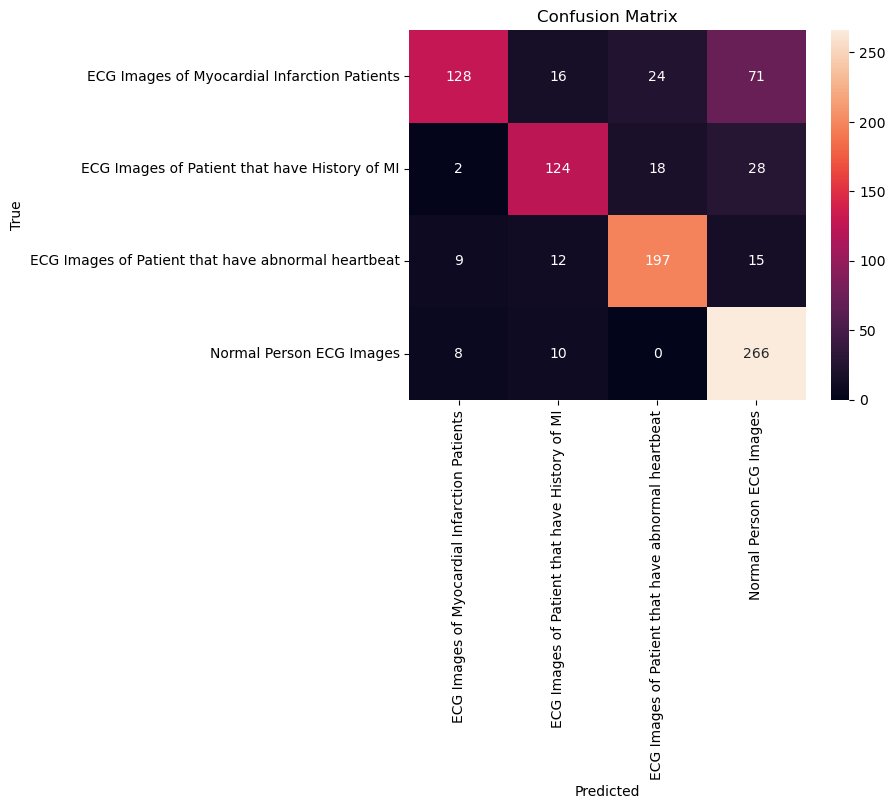

Hybrid - Epoch 1: Train Loss: 1.2642, Train Acc: 0.3950, Val Acc: 0.5339
Hybrid - Epoch 2: Train Loss: 1.0139, Train Acc: 0.5558, Val Acc: 0.5950
Hybrid - Epoch 3: Train Loss: 0.8758, Train Acc: 0.6377, Val Acc: 0.6893
Hybrid - Epoch 4: Train Loss: 0.7632, Train Acc: 0.7014, Val Acc: 0.7091
Hybrid - Epoch 5: Train Loss: 0.7036, Train Acc: 0.7287, Val Acc: 0.7157
Hybrid - Epoch 6: Train Loss: 0.6394, Train Acc: 0.7502, Val Acc: 0.7603
Hybrid - Epoch 7: Train Loss: 0.6078, Train Acc: 0.7676, Val Acc: 0.7471
Hybrid - Epoch 8: Train Loss: 0.5798, Train Acc: 0.7701, Val Acc: 0.7653
Hybrid - Epoch 9: Train Loss: 0.5862, Train Acc: 0.7771, Val Acc: 0.8050
Hybrid - Epoch 10: Train Loss: 0.5641, Train Acc: 0.7862, Val Acc: 0.7620
Hybrid - Epoch 11: Train Loss: 0.5236, Train Acc: 0.7978, Val Acc: 0.7818
Hybrid - Epoch 12: Train Loss: 0.5083, Train Acc: 0.7974, Val Acc: 0.8132
Hybrid - Epoch 13: Train Loss: 0.5035, Train Acc: 0.8143, Val Acc: 0.7802
Hybrid - Epoch 14: Train Loss: 0.5224, Train Ac

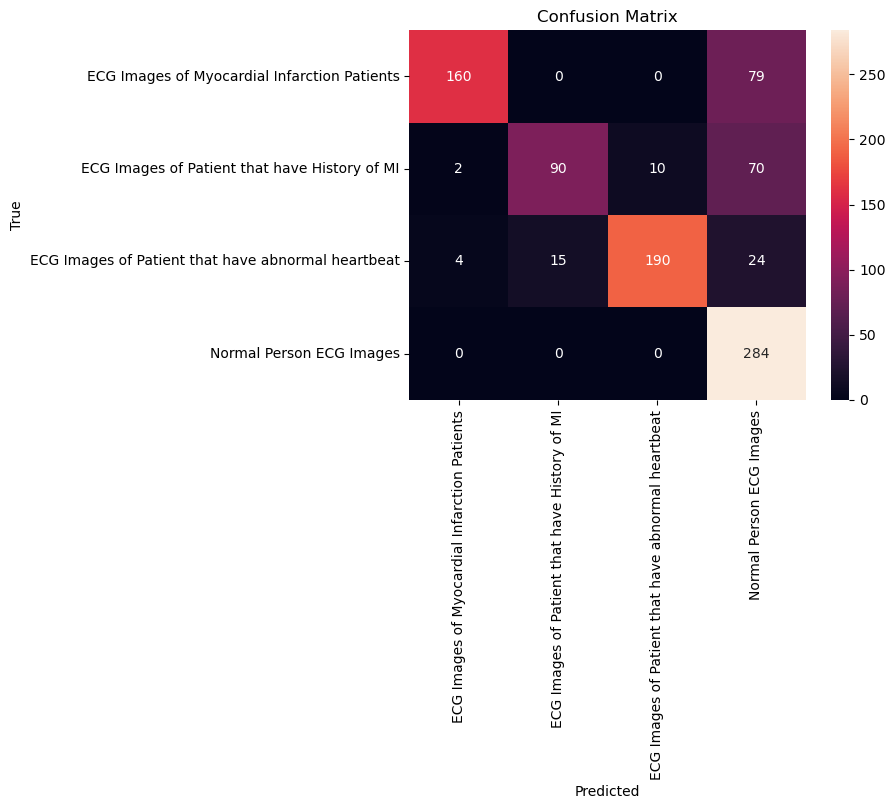

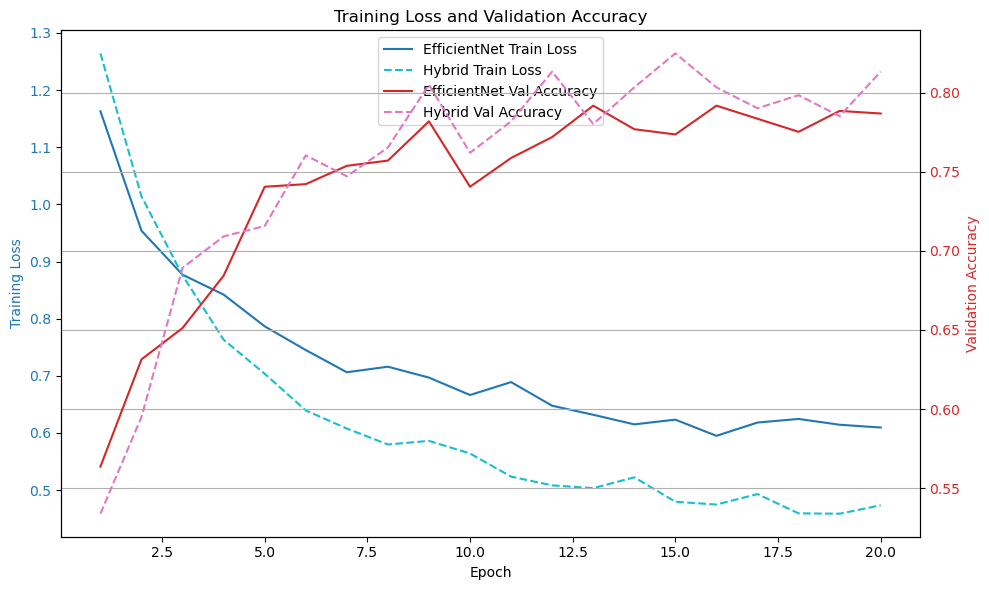

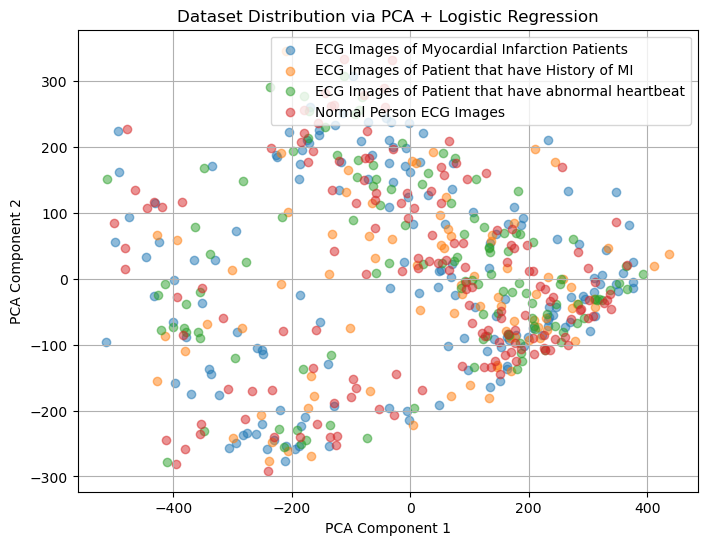

In [1]:
# === Required Libraries ===
import os
import torch
import torchvision.transforms as transforms
from torchvision import datasets, models
from torch.utils.data import DataLoader, random_split
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.linear_model import LogisticRegression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from transformers import ViTModel, ViTFeatureExtractor
from torchvision.models import efficientnet_b0

# === Device Setup ===
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# === Paths ===
data_dir = "C:/Users/25902491/Desktop/data for ecg/ECG_DATA/train"
test_dir = "C:/Users/25902491/Desktop/data for ecg/ECG_DATA/test"

# === Data Transforms ===
image_size = 224
transform_train = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.RandomResizedCrop(image_size, scale=(0.8, 1.0)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.1),
    transforms.RandomAffine(degrees=0, translate=(0.05, 0.05), shear=5),
    transforms.RandomPerspective(distortion_scale=0.2, p=0.3),
    transforms.ToTensor(),
    transforms.RandomErasing(p=0.2, scale=(0.02, 0.1), ratio=(0.3, 3.3)),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

transform_test = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# === Dataset Loading and Splitting ===
full_dataset = datasets.ImageFolder(data_dir, transform=transform_train)
test_dataset = datasets.ImageFolder(test_dir, transform=transform_test)

train_size = int(0.8 * len(full_dataset))
val_size = len(full_dataset) - train_size
train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False)

class_names = full_dataset.classes

# === EfficientNet Setup ===
efficientnet = efficientnet_b0(pretrained=True)
for param in efficientnet.parameters():
    param.requires_grad = False
for param in efficientnet.features[-2:].parameters():
    param.requires_grad = True
for param in efficientnet.classifier.parameters():
    param.requires_grad = True

efficientnet.classifier[1] = nn.Linear(efficientnet.classifier[1].in_features, len(class_names))
efficientnet = efficientnet.to(device)

# === Hybrid EfficientNet + ViT Model ===
class HybridEfficientNetViT(nn.Module):
    def __init__(self, num_classes):
        super(HybridEfficientNetViT, self).__init__()
        self.efficientnet = efficientnet_b0(pretrained=True)
        for param in self.efficientnet.parameters():
            param.requires_grad = False
        for param in self.efficientnet.features[-2:].parameters():
            param.requires_grad = True
        self.efficientnet_features = nn.Sequential(*list(self.efficientnet.children())[:-1])

        self.vit = ViTModel.from_pretrained('google/vit-base-patch16-224-in21k')
        for param in self.vit.parameters():
            param.requires_grad = False
        for param in self.vit.encoder.layer[-2:].parameters():
            param.requires_grad = True
        self.feature_extractor = ViTFeatureExtractor.from_pretrained('google/vit-base-patch16-224-in21k')

        self.classifier = nn.Sequential(
            nn.Linear(1280 + 768, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )

    def forward(self, x):
        eff_feat = self.efficientnet_features(x)
        eff_feat = torch.flatten(eff_feat, 1)
        vit_input = torch.nn.functional.interpolate(x, size=(224, 224))
        vit_outputs = self.vit(pixel_values=vit_input).last_hidden_state[:, 0, :]
        combined = torch.cat((eff_feat, vit_outputs), dim=1)
        return self.classifier(combined)

hybrid_model = HybridEfficientNetViT(len(class_names)).to(device)

# === Evaluation Functions ===
def evaluate_model(model, dataloader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
    return correct / total

def test_and_report(model, dataloader):
    model.eval()
    all_preds = []
    all_labels = []
    with torch.no_grad():
        for images, labels in dataloader:
            images = images.to(device)
            outputs = model(images)
            _, preds = torch.max(outputs, 1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.numpy())
    print(classification_report(all_labels, all_preds, target_names=class_names))
    cm = confusion_matrix(all_labels, all_preds)
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

# === Training Function ===
def train_model(model, dataloaders, criterion, optimizer, scheduler, model_name="model", epochs=20):
    train_losses, val_accuracies = [], []
    for epoch in range(epochs):
        model.train()
        running_loss, correct = 0.0, 0
        total = 0
        for images, labels in dataloaders['train']:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * images.size(0)
            _, preds = torch.max(outputs, 1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)
        scheduler.step()
        epoch_loss = running_loss / total
        epoch_acc = correct / total
        val_acc = evaluate_model(model, dataloaders['val'])
        train_losses.append(epoch_loss)
        val_accuracies.append(val_acc)
        print(f"{model_name} - Epoch {epoch+1}: Train Loss: {epoch_loss:.4f}, Train Acc: {epoch_acc:.4f}, Val Acc: {val_acc:.4f}")
    return train_losses, val_accuracies

# === Combined Plot: Training Loss & Validation Accuracy ===
def compare_training_curves(metrics1, metrics2, label1="Model 1", label2="Model 2"):
    train_loss1, val_acc1 = metrics1
    train_loss2, val_acc2 = metrics2
    epochs = list(range(1, len(train_loss1) + 1))

    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Training Loss', color='tab:blue')
    ax1.plot(epochs, train_loss1, label=f"{label1} Train Loss", linestyle='-', color='tab:blue')
    ax1.plot(epochs, train_loss2, label=f"{label2} Train Loss", linestyle='--', color='tab:cyan')
    ax1.tick_params(axis='y', labelcolor='tab:blue')

    ax2 = ax1.twinx()
    ax2.set_ylabel('Validation Accuracy', color='tab:red')
    ax2.plot(epochs, val_acc1, label=f"{label1} Val Accuracy", linestyle='-', color='tab:red')
    ax2.plot(epochs, val_acc2, label=f"{label2} Val Accuracy", linestyle='--', color='tab:pink')
    ax2.tick_params(axis='y', labelcolor='tab:red')

    lines1, labels1 = ax1.get_legend_handles_labels()
    lines2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper center')

    plt.title("Training Loss and Validation Accuracy")
    plt.grid(True)
    fig.tight_layout()
    plt.show()

# === Logistic Regression PCA Scatter Plot ===
def visualize_with_logistic_regression(loader, model_name="Dataset Distribution"):
    features, labels = [], []
    for images, lbls in loader:
        flat = images.view(images.size(0), -1)
        features.append(flat.numpy())
        labels.extend(lbls.numpy())
        if len(labels) > 500:
            break
    X = np.vstack(features)
    y = np.array(labels)
    pca = PCA(n_components=2)
    X_pca = pca.fit_transform(X)
    clf = LogisticRegression(max_iter=200)
    clf.fit(X_pca, y)
    plt.figure(figsize=(8, 6))
    for c in np.unique(y):
        plt.scatter(X_pca[y == c, 0], X_pca[y == c, 1], label=class_names[c], alpha=0.5)
    plt.title(f"{model_name} via PCA + Logistic Regression")
    plt.xlabel("PCA Component 1")
    plt.ylabel("PCA Component 2")
    plt.legend()
    plt.grid(True)
    plt.show()

# === Optimizers and Schedulers ===
effnet_optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, efficientnet.parameters()),
    lr=0.01, momentum=0.9, weight_decay=1e-4
)
effnet_scheduler = torch.optim.lr_scheduler.StepLR(effnet_optimizer, step_size=5, gamma=0.5)

hybrid_optimizer = torch.optim.SGD(
    filter(lambda p: p.requires_grad, hybrid_model.parameters()),
    lr=0.01, momentum=0.9, weight_decay=1e-4
)
hybrid_scheduler = torch.optim.lr_scheduler.StepLR(hybrid_optimizer, step_size=5, gamma=0.5)

# === Training and Evaluation ===
effnet_metrics = train_model(
    efficientnet,
    {'train': train_loader, 'val': val_loader},
    nn.CrossEntropyLoss(),
    effnet_optimizer,
    effnet_scheduler,
    model_name="EfficientNet",
    epochs=20
)
test_and_report(efficientnet, test_loader)

hybrid_metrics = train_model(
    hybrid_model,
    {'train': train_loader, 'val': val_loader},
    nn.CrossEntropyLoss(),
    hybrid_optimizer,
    hybrid_scheduler,
    model_name="Hybrid",
    epochs=20
)
test_and_report(hybrid_model, test_loader)

# === Training Curve Comparison Plot ===
compare_training_curves(effnet_metrics, hybrid_metrics, label1="EfficientNet", label2="Hybrid")

# === Logistic Regression Scatter Plot ===
visualize_with_logistic_regression(train_loader)
